In [1]:
import itertools as it

import boto3
import botocore
from cliffs_delta import cliffs_delta
import numpy as np
import pandas as pd
from pandas.util import hash_pandas_object
from scipy import stats as scipy_stats
import seaborn as sns
import seaborn.objects as so
from teeplot import teeplot as tp


In [2]:
from dishpylib.pyhelpers import make_outattr_metadata
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervm7g52i
interpreter: 3.10.12 (main, Jul 15 2026, 23:40:17) [GCC 11.4.0]
notebook name: 2026-08-18-complexty-fitness-correlation
notebook path: /home/runner/work/oee4/oee4/binder/2026-08-18-complexty-fitness-correlation.ipynb
revision: bdac574
timestamp: 2026-09-21T18:56:44Z00:00

IPython==7.16.1
packaging==26.2


<ipython-input-3-4d790cf6450f>:1: DeprecatedWarning: print_runtime is deprecated. use nbmetalog package instead
  print_runtime()


In [4]:
teeplot_subdir = "2026-08-18-complexty-fitness-correlation"


# get data


In [5]:
s3_handle = boto3.resource(
    's3',
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket('prq49')

series_profiles, = bucket_handle.objects.filter(
    Prefix=f'endeavor=16/series-profiles/stage=8+what=elaborated/',
)


In [6]:
df = pd.read_csv(
    f's3://prq49/{series_profiles.key}',
    compression='xz',
)
dfdigest = '{:x}'.format( hash_pandas_object( df ).sum() )
dfdigest


<ipython-input-6-747b1fe91af5>:1: DtypeWarning: Columns (286,293,300,301,302,303,305,306,307,308,314,315,316,317,318,324,325,326) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


'-333308f100cbd3f8'

In [7]:
def make_outattr_metadata():
    return {}


In [8]:
for stint in df['Stint'].unique():
    exec(f'df{stint} = df[ df["Stint"] == {stint} ]')


In [9]:
dfm10 = df[ df['Stint'] % 10 == 9 ]  # rerun for replication/complete data @ stint 9, 19, 29, 39, 49, 59, 69, 79, 89, 99


In [10]:
s3_handle = boto3.resource(
    "s3",
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket("prq49")

dfnone = pd.concat(
    [
        pd.read_csv(f"s3://prq49/{item.key}")
        for item in bucket_handle.objects.filter(
            Prefix=f"endeavor=16/external-competitions/stage=2+what=collated/",
        )
    ],
    ignore_index=True,
)
dfnone["kind"] = "none"
print(dfnone["Competition Stint"].unique())
print(dfnone["Competition Series"].unique())


[  1  10 100  11  12  13  14  15  16  17  18  19   2  20  21  22  23  24
  25  26  27  28  29   3  30  31  32  33  34  35  36  37  38  39   4  40
  41  42  43  44  45  46  47  48  49   5  50  51  52  53  54  55  56  57
  58  59   6  60  61  62  63  64  65  66  67  68  69   7  70  71  72  73
  74  75  76  77  78  79   8  80  81  82  83  84  85  86  87  88  89   9
  90  91  92  93  94  95  96  97  98  99]
[16005 16000 16001 16002 16003 16004 16006 16007 16008 16009 16010 16011
 16012 16013 16014 16015 16016 16017 16018 16019 16020 16021 16022 16023
 16024 16025 16026 16027 16028 16029 16030 16031 16032 16033 16034 16035
 16036 16037 16038 16039]


In [11]:
dfx = dfnone[
    dfnone['Competition Stint'] % 10 == 9
].copy()
dfx["Fitness Differential Focal Sign"] = np.sign(
    dfx["Fitness Differential Focal"],
)
dfx["Series"] = dfx["Competition Series"]
dfx["Stint"] = dfx["Competition Stint"]
dfx["flip series"] = dfx["genome series"] * (dfx["Root ID"] == 1)
dfx["Competitor"] = (
    dfx
    .groupby(["Stint", "Series", "kind", "Competition Repro"])
    ["flip series"]
    .transform("max")
)
dfx = dfx[
    dfx["Root ID"] == 0
].groupby(["Stint", "Series", "kind", "Competitor"])[
    "Focal Prevalence"
].mean().round().reset_index(drop=False)
dfx


,Stint,Series,kind,Competitor,Focal Prevalence
0,9,16000,none,16000,0.0
1,9,16000,none,16001,0.0
2,9,16000,none,16002,0.0
3,9,16000,none,16003,0.0
4,9,16000,none,16004,0.0
...,...,...,...,...,...
15995,99,16039,none,16035,0.0
15996,99,16039,none,16036,1.0
15997,99,16039,none,16037,0.0
15998,99,16039,none,16038,0.0


In [12]:
dfj = dfx.join(
    dfm10[
        [
            "Stint",
            "Series",
            "Fitness Complexity",
            "Flagged Advantageous Sites",
            "Flagged Deleterious Sites",
            "Cardinal Interface Complexity",
            "Cell Interface Complexity",
        ]
    ].set_index(
        ["Stint", "Series"]
    ),
    on=["Stint", "Series"],
    how="inner",
).reset_index(drop=False)
dfj["Favored"] = dfj["Focal Prevalence"] > 0.5
dfj


,index,Stint,Series,kind,Competitor,Focal Prevalence,Fitness Complexity,Flagged Advantageous Sites,Flagged Deleterious Sites,Cardinal Interface Complexity,Cell Interface Complexity,Favored
0,0,9,16000,none,16000,0.0,12.37,13.0,5.0,3.0,2.0,False
1,1,9,16000,none,16001,0.0,12.37,13.0,5.0,3.0,2.0,False
2,2,9,16000,none,16002,0.0,12.37,13.0,5.0,3.0,2.0,False
3,3,9,16000,none,16003,0.0,12.37,13.0,5.0,3.0,2.0,False
4,4,9,16000,none,16004,0.0,12.37,13.0,5.0,3.0,2.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...
15995,15995,99,16039,none,16035,0.0,13.09,14.0,0.0,2.0,2.0,False
15996,15996,99,16039,none,16036,1.0,13.09,14.0,0.0,2.0,2.0,True
15997,15997,99,16039,none,16037,0.0,13.09,14.0,0.0,2.0,2.0,False
15998,15998,99,16039,none,16038,0.0,13.09,14.0,0.0,2.0,2.0,False


In [13]:
palette = [
    sns.color_palette("Dark2")[2],
    sns.color_palette("Dark2")[4],
    sns.color_palette("Dark2")[0],
]


In [14]:
light_palette=[
    "#a3cf73",
    "#6dceb1",
]
dark_palette=[
    "#4a772f",
    "#137177",
]


## Fitness


0
teeplots/2026-08-18-complexty-fitness-correlation/agg=True+viz=lmplot+when=early+x=phenotype-complexity+y=focal-prevalence+ext=.pdf
teeplots/2026-08-18-complexty-fitness-correlation/agg=True+viz=lmplot+when=early+x=phenotype-complexity+y=focal-prevalence+ext=.png


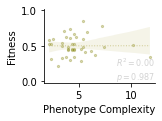

0
teeplots/2026-08-18-complexty-fitness-correlation/agg=False+viz=lmplot+when=early+x=phenotype-complexity+y=focal-prevalence+ext=.pdf
teeplots/2026-08-18-complexty-fitness-correlation/agg=False+viz=lmplot+when=early+x=phenotype-complexity+y=focal-prevalence+ext=.png


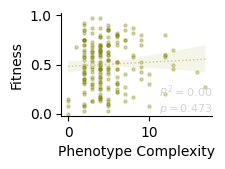

0
teeplots/2026-08-18-complexty-fitness-correlation/agg=True+viz=lmplot+when=late+x=phenotype-complexity+y=focal-prevalence+ext=.pdf
teeplots/2026-08-18-complexty-fitness-correlation/agg=True+viz=lmplot+when=late+x=phenotype-complexity+y=focal-prevalence+ext=.png


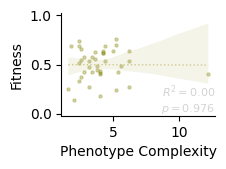

0
teeplots/2026-08-18-complexty-fitness-correlation/agg=False+viz=lmplot+when=late+x=phenotype-complexity+y=focal-prevalence+ext=.pdf
teeplots/2026-08-18-complexty-fitness-correlation/agg=False+viz=lmplot+when=late+x=phenotype-complexity+y=focal-prevalence+ext=.png


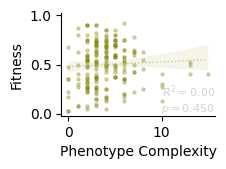

0
teeplots/2026-08-18-complexty-fitness-correlation/agg=True+viz=lmplot+when=all+x=phenotype-complexity+y=focal-prevalence+ext=.pdf
teeplots/2026-08-18-complexty-fitness-correlation/agg=True+viz=lmplot+when=all+x=phenotype-complexity+y=focal-prevalence+ext=.png


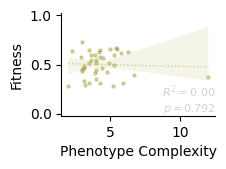

0
teeplots/2026-08-18-complexty-fitness-correlation/agg=False+viz=lmplot+when=all+x=phenotype-complexity+y=focal-prevalence+ext=.pdf
teeplots/2026-08-18-complexty-fitness-correlation/agg=False+viz=lmplot+when=all+x=phenotype-complexity+y=focal-prevalence+ext=.png


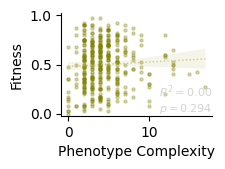

In [15]:
for (y, when, agg) in it.product(
    ["Focal Prevalence"],
    ["early", "late", "all"],
    [True, False],
):
    # 1. Base Aggregation
    dfjx = dfj.groupby(
        ["Series", "kind", "Stint"],
    ).mean().reset_index(drop=False)

    # 2. Separate Baseline (eco) and Target (self)
    df_none = dfjx[dfjx["kind"] == "none"].copy()

    # 5. Prepare Plot Data (Aggregated)
    whenisin = {
        "early": range(9, 51, 10),
        "late": range(59, 101, 10),
        "all": range(9, 101, 10),
    }[when]

    df_plot = df_none[
        df_none["Stint"].isin(whenisin)
    ].reset_index(drop=True)
    df_plot["Phenotype Complexity"] = df_plot["Cardinal Interface Complexity"]

    print(df_plot["Phenotype Complexity"].isnull().sum())  # Check for NaN values in Phenotype Complexity

    if agg:
        df_plot = df_plot.groupby(["Series"]).mean().reset_index(drop=False)

    # 6. Calculate Regression Stats
    slope, intercept, r_value, p_value, std_err = scipy_stats.linregress(
        df_plot["Phenotype Complexity"],
        df_plot[y]
    )

    # Determine significance
    is_significant = p_value < 0.05

    # Format the annotation text with bold if significant
    if is_significant:
        stats_text = (
            f"$\\mathbf{{R^2 = {r_value**2:.2f}}}$\n"
            f"$\\mathbf{{p = {p_value:{'.1e' if p_value < 0.01 else '.3f'}}}}$"
        )
    else:
        stats_text = (
            f"$R^2 = {r_value**2:.2f}$\n"
            f"$p = {p_value:{'.1e' if p_value < 0.01 else '.3f'}}$"
        )

    # 7. Plot
    with tp.teed(
        sns.lmplot,
        data=df_plot,
        x="Phenotype Complexity",
        y=y,
        line_kws={"lw": 1.0, "alpha": 0.7, "color": "darkkhaki", "linestyle": '-' if is_significant else ':'},
        scatter_kws={"color": "olive", "alpha": 0.3, "clip_on": False, "s": 5},
        facet_kws=dict(
            sharex=False,
            sharey=True,
        ),
        teeplot_outattrs={"agg": agg, "when": when},
        teeplot_subdir=teeplot_subdir,
    ) as g:
        g.figure.set_size_inches(2, 1.2)  # Adjusted size for single plot
        g.set_xlabels("Phenotype Complexity")
        g.set_ylabels("Fitness")

        # Add a horizontal reference line
        ax = g.axes.flat[0]
        ax.set_ylim(-0.02, 1.02)

        # Add the stats annotation to the plot
        # Anchored to upper left or right depending on data layout
        g.figure.subplots_adjust(left=0.2)
        ax.text(
            1, 0,
            stats_text,
            transform=ax.transAxes,
            horizontalalignment='right',
            verticalalignment='bottom',
            fontsize=8,
            color="black" if is_significant else "lightgray",
            weight="bold" if is_significant else "normal",
        )


     Series  kind  Stint   index  Competitor  Focal Prevalence  \
295   16029  none     59  9179.5     16019.5             0.075   

     Fitness Complexity  Flagged Advantageous Sites  \
295                 NaN                         NaN   

     Flagged Deleterious Sites  Cardinal Interface Complexity  \
295                        NaN                            1.0   

     Cell Interface Complexity  Favored  Genetic Complexity  
295                        1.0    0.075                 NaN  
0
teeplots/2026-08-18-complexty-fitness-correlation/agg=True+viz=lmplot+when=early+x=genetic-complexity+y=focal-prevalence+ext=.pdf
teeplots/2026-08-18-complexty-fitness-correlation/agg=True+viz=lmplot+when=early+x=genetic-complexity+y=focal-prevalence+ext=.png


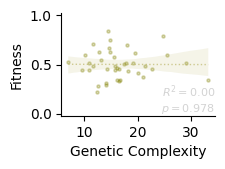

     Series  kind  Stint   index  Competitor  Focal Prevalence  \
295   16029  none     59  9179.5     16019.5             0.075   

     Fitness Complexity  Flagged Advantageous Sites  \
295                 NaN                         NaN   

     Flagged Deleterious Sites  Cardinal Interface Complexity  \
295                        NaN                            1.0   

     Cell Interface Complexity  Favored  Genetic Complexity  
295                        1.0    0.075                 NaN  
0
teeplots/2026-08-18-complexty-fitness-correlation/agg=False+viz=lmplot+when=early+x=genetic-complexity+y=focal-prevalence+ext=.pdf
teeplots/2026-08-18-complexty-fitness-correlation/agg=False+viz=lmplot+when=early+x=genetic-complexity+y=focal-prevalence+ext=.png


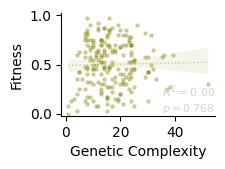

     Series  kind  Stint   index  Competitor  Focal Prevalence  \
295   16029  none     59  9179.5     16019.5             0.075   

     Fitness Complexity  Flagged Advantageous Sites  \
295                 NaN                         NaN   

     Flagged Deleterious Sites  Cardinal Interface Complexity  \
295                        NaN                            1.0   

     Cell Interface Complexity  Favored  Genetic Complexity  
295                        1.0    0.075                 NaN  
0
teeplots/2026-08-18-complexty-fitness-correlation/agg=True+viz=lmplot+when=late+x=genetic-complexity+y=focal-prevalence+ext=.pdf
teeplots/2026-08-18-complexty-fitness-correlation/agg=True+viz=lmplot+when=late+x=genetic-complexity+y=focal-prevalence+ext=.png


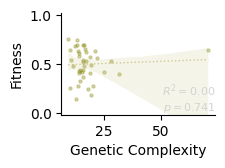

     Series  kind  Stint   index  Competitor  Focal Prevalence  \
295   16029  none     59  9179.5     16019.5             0.075   

     Fitness Complexity  Flagged Advantageous Sites  \
295                 NaN                         NaN   

     Flagged Deleterious Sites  Cardinal Interface Complexity  \
295                        NaN                            1.0   

     Cell Interface Complexity  Favored  Genetic Complexity  
295                        1.0    0.075                 NaN  
0
teeplots/2026-08-18-complexty-fitness-correlation/agg=False+viz=lmplot+when=late+x=genetic-complexity+y=focal-prevalence+ext=.pdf
teeplots/2026-08-18-complexty-fitness-correlation/agg=False+viz=lmplot+when=late+x=genetic-complexity+y=focal-prevalence+ext=.png


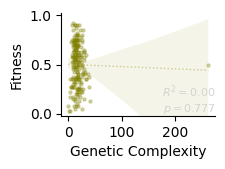

     Series  kind  Stint   index  Competitor  Focal Prevalence  \
295   16029  none     59  9179.5     16019.5             0.075   

     Fitness Complexity  Flagged Advantageous Sites  \
295                 NaN                         NaN   

     Flagged Deleterious Sites  Cardinal Interface Complexity  \
295                        NaN                            1.0   

     Cell Interface Complexity  Favored  Genetic Complexity  
295                        1.0    0.075                 NaN  
0
teeplots/2026-08-18-complexty-fitness-correlation/agg=True+viz=lmplot+when=all+x=genetic-complexity+y=focal-prevalence+ext=.pdf
teeplots/2026-08-18-complexty-fitness-correlation/agg=True+viz=lmplot+when=all+x=genetic-complexity+y=focal-prevalence+ext=.png


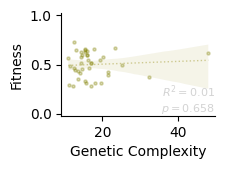

     Series  kind  Stint   index  Competitor  Focal Prevalence  \
295   16029  none     59  9179.5     16019.5             0.075   

     Fitness Complexity  Flagged Advantageous Sites  \
295                 NaN                         NaN   

     Flagged Deleterious Sites  Cardinal Interface Complexity  \
295                        NaN                            1.0   

     Cell Interface Complexity  Favored  Genetic Complexity  
295                        1.0    0.075                 NaN  
0
teeplots/2026-08-18-complexty-fitness-correlation/agg=False+viz=lmplot+when=all+x=genetic-complexity+y=focal-prevalence+ext=.pdf
teeplots/2026-08-18-complexty-fitness-correlation/agg=False+viz=lmplot+when=all+x=genetic-complexity+y=focal-prevalence+ext=.png


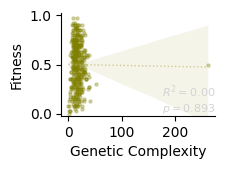

In [16]:
for (y, when, agg) in it.product(
    ["Focal Prevalence"],
    ["early", "late", "all"],
    [True, False],
):
    # 1. Base Aggregation
    dfjx = dfj.groupby(
        ["Series", "kind", "Stint"],
    ).mean().reset_index(drop=False)

    # 2. Separate Baseline (eco) and Target (self)
    df_none = dfjx[dfjx["kind"] == "none"].copy()

    # 5. Prepare Plot Data (Aggregated)
    whenisin = {
        "early": range(9, 51, 10),
        "late": range(59, 101, 10),
        "all": range(9, 101, 10),
    }[when]
    df_none["Genetic Complexity"] = df_none["Flagged Advantageous Sites"]

    print(df_none[
        df_none["Genetic Complexity"].isnull()
    ])  # Check for NaN values in Genetic Complexity
    # Series 1029/stint 9 has NaN values because all sites were detected as phenotype-equivalent
    # Thus, it can be filled as zero
    df_none["Genetic Complexity"].fillna(0, inplace=True)
    print(df_none["Genetic Complexity"].isnull().sum())  # Check again for NaN values in Genetic Complexity

    df_plot = df_none[
        df_none["Stint"].isin(whenisin)
    ].reset_index(drop=True)
    if agg:
        df_plot = df_plot.groupby(["Series"]).mean().reset_index(drop=False)

    # 6. Calculate Regression Stats
    slope, intercept, r_value, p_value, std_err = scipy_stats.linregress(
        df_plot["Genetic Complexity"],
        df_plot[y]
    )

    # Determine significance
    is_significant = p_value < 0.05

    # Format the annotation text with bold if significant
    if is_significant:
        stats_text = (
            f"$\\mathbf{{R^2 = {r_value**2:.2f}}}$\n"
            f"$\\mathbf{{p = {p_value:{'.1e' if p_value < 0.01 else '.3f'}}}}$"
        )
    else:
        stats_text = (
            f"$R^2 = {r_value**2:.2f}$\n"
            f"$p = {p_value:{'.1e' if p_value < 0.01 else '.3f'}}$"
        )

    # 7. Plot
    with tp.teed(
        sns.lmplot,
        data=df_plot,
        x="Genetic Complexity",
        y=y,
        line_kws={"lw": 1.0, "alpha": 0.7, "color": "darkkhaki", "linestyle": '-' if is_significant else ':'},
        scatter_kws={"color": "olive", "alpha": 0.3, "clip_on": False, "s": 5},
        facet_kws=dict(
            sharex=False,
            sharey=True,
        ),
        teeplot_outattrs={"agg": agg, "when": when},
        teeplot_subdir=teeplot_subdir,
    ) as g:
        g.figure.set_size_inches(2, 1.2)  # Adjusted size for single plot
        g.set_xlabels("Genetic Complexity")
        g.set_ylabels("Fitness")

        # Add a horizontal reference line
        ax = g.axes.flat[0]
        ax.set_ylim(-0.02, 1.02)

        # Add the stats annotation to the plot
        # Anchored to upper left or right depending on data layout
        g.figure.subplots_adjust(left=0.2)
        ax.text(
            1, 0,
            stats_text,
            transform=ax.transAxes,
            horizontalalignment='right',
            verticalalignment='bottom',
            fontsize=8,
            color="black" if is_significant else "lightgray",
            weight="bold" if is_significant else "normal",
        )
